In [ ]:
import numpy as np

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Регуляризация (C = 1/lambda)
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Превращаем метки 0/1 в -1/1
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Условие корректной классификации с учетом отступа
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Только штраф за веса (L2 регуляризация)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Штраф за веса + ошибка классификации (Hinge Loss)
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
# Загрузка и подготовка данных
data = datasets.load_breast_cancer()
X, y = data.data, data.target

# SVM чувствителен к масштабу признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [3]:
# Определение сетки параметров
param_grid = {
    'C': [0.1, 1, 10, 100],            # Параметр мягкого отступа
    'gamma': [1, 0.1, 0.01, 0.001],    # Коэффициент ядра (для rbf, poly, sigmoid)
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Поиск лучших параметров с кросс-валидацией
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'sigmoid']})

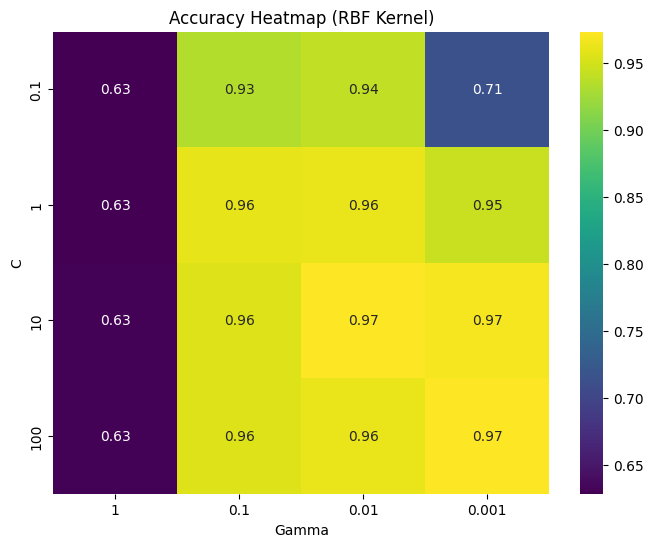

Лучшие параметры: {'C': 100, 'gamma': 0.001, 'kernel': 'sigmoid'}
Точность на тестовой выборке: 0.9825


In [4]:
# Визуализация тепловой карты (для ядра RBF)
# Извлекаем результаты и меняем форму для Heatmap
results = grid.cv_results_
# Выбираем только результаты, где kernel == 'rbf'
scores = results['mean_test_score'][results['param_kernel'] == 'rbf'].reshape(4, 4)

plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'], cmap='viridis')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.title('Accuracy Heatmap (RBF Kernel)')
plt.show()

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Точность на тестовой выборке: {grid.score(X_test, y_test):.4f}")

# Контекст:
В астрономии классификация звезд — это классификация звезд на основе их спектральных характеристик. Схема классификации галактик, квазаров и звезд является одной из самых фундаментальных в астрономии. Ранняя каталогизация звезд и их распределения на небе привела к пониманию того, что они составляют нашу собственную галактику, и после того, как было установлено, что Андромеда является отдельной галактикой от нашей, многие галактики начали изучаться по мере создания более мощных телескопов. Цель этого спутника данных — классифицировать звезды, галактики и квазары на основе их спектральных характеристик.

# Содержание:

Данные состоят из 100 000 наблюдений космического пространства, выполненных в рамках проекта SDSS (Sloan Digital Sky Survey). Каждое наблюдение описывается 17 столбцами характеристик и 1 столбцом класса, который определяет, является ли оно звездой, галактикой или квазаром.

# Задание:
Выполнить предобработку данных: обработать выбросы и пропущенные значения (если они есть)

Использовать алгоритм SVM, построить тепловую карту для подбора значений gamma и C

Вывести наилучшую точность модели

In [ ]:
# obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
# alpha = Right Ascension angle (at J2000 epoch)
# delta = Declination angle (at J2000 epoch)
# u = Ultraviolet filter in the photometric system
# g = Green filter in the photometric system
# r = Red filter in the photometric system
# i = Near Infrared filter in the photometric system
# z = Infrared filter in the photometric system
# run_ID = Run Number used to identify the specific scan
# rereun_ID = Rerun Number to specify how the image was processed
# cam_col = Camera column to identify the scanline within the run
# field_ID = Field number to identify each field
# spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
# class = object class (galaxy, star or quasar object)
# redshift = redshift value based on the increase in wavelength
# plate = plate ID, identifies each plate in SDSS
# MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
# fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('/content/sample_data/star_classification.csv')

In [8]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
